In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:

    sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from src.config import (
    PROCESSED_DATA_DIR,
    TABLES_DIR,
    GRAPHS_DIR
)

from src.data_loader import load_clean_data

from src.trend_analysis import calculate_linear_trend

from src.visualization import save_plot

%matplotlib inline

plt.style.use("ggplot")

In [3]:
climate_df = load_clean_data(
    PROCESSED_DATA_DIR /
    "climate_trend_clean.csv"
)

climate_df.head()

,Year,J-D
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


In [4]:
climate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    147 non-null    int64  
 1   J-D     146 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


In [5]:
print(climate_df.columns)
print(climate_df.head())


Index(['Year', 'J-D'], dtype='str')
   Year   J-D
0  1880 -0.18
1  1881 -0.09
2  1882 -0.11
3  1883 -0.18
4  1884 -0.29


In [6]:
# rename column expected by calculate_linear_trend without altering original df
df_for_trend = climate_df.rename(columns={'J-D': 'Temperature_Anomaly'})

trend = calculate_linear_trend(df_for_trend)

trend

LinregressResult(slope=np.float64(nan), intercept=np.float64(nan), rvalue=np.float64(nan), pvalue=np.float64(nan), stderr=np.float64(nan), intercept_stderr=np.float64(nan))

In [7]:
trend_metrics = pd.DataFrame({

    "Metric":[
        "Slope",
        "Intercept",
        "Correlation",
        "P-Value",
        "Standard Error"
    ],

    "Value":[
        trend.slope,
        trend.intercept,
        trend.rvalue,
        trend.pvalue,
        trend.stderr
    ]
})

trend_metrics

,Metric,Value
0,Slope,NaN
1,Intercept,NaN
2,Correlation,NaN
3,P-Value,NaN
4,Standard Error,NaN


In [8]:
trend_metrics.to_csv(
    TABLES_DIR /
    "regression_metrics.csv",
    index=False
)

In [9]:
print(trend_metrics)

           Metric  Value
0           Slope    NaN
1       Intercept    NaN
2     Correlation    NaN
3         P-Value    NaN
4  Standard Error    NaN


In [10]:
climate_df.head()

,Year,J-D
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


In [11]:
print(climate_df.shape)

(147, 2)


In [12]:
from src.trend_analysis import calculate_linear_trend

trend = calculate_linear_trend(df_for_trend)

print(trend)

LinregressResult(slope=np.float64(nan), intercept=np.float64(nan), rvalue=np.float64(nan), pvalue=np.float64(nan), stderr=np.float64(nan), intercept_stderr=np.float64(nan))


In [13]:
print(trend.slope)

nan


In [14]:
trend_metrics = pd.DataFrame({
    "Metric": [
        "Slope",
        "Intercept",
        "Correlation",
        "P-Value",
        "Standard Error"
    ],
    "Value": [
        trend.slope,
        trend.intercept,
        trend.rvalue,
        trend.pvalue,
        trend.stderr
    ]
})

trend_metrics

,Metric,Value
0,Slope,NaN
1,Intercept,NaN
2,Correlation,NaN
3,P-Value,NaN
4,Standard Error,NaN


In [15]:
print(trend)

LinregressResult(slope=np.float64(nan), intercept=np.float64(nan), rvalue=np.float64(nan), pvalue=np.float64(nan), stderr=np.float64(nan), intercept_stderr=np.float64(nan))


In [16]:
print(climate_df.isnull().sum())

Year    0
J-D     1
dtype: int64


In [17]:
print(climate_df.head(10))

   Year   J-D
0  1880 -0.18
1  1881 -0.09
2  1882 -0.11
3  1883 -0.18
4  1884 -0.29
5  1885 -0.34
6  1886 -0.32
7  1887 -0.36
8  1888 -0.18
9  1889 -0.11


In [18]:
print(climate_df.dtypes)

Year      int64
J-D     float64
dtype: object


In [19]:
print(df_for_trend[df_for_trend["Temperature_Anomaly"].isna()])

     Year  Temperature_Anomaly
146  2026                  NaN


In [20]:
print(df_for_trend["Temperature_Anomaly"].isna().sum())

1


In [22]:
climate_df["Temperature_Anomaly"] = pd.to_numeric(
    climate_df["J-D"],
    errors="coerce"
)

print(climate_df.dtypes)

Year                     int64
J-D                    float64
Temperature_Anomaly    float64
dtype: object


In [23]:
from scipy.stats import linregress


def calculate_linear_trend(df):
    """
    Calculate linear regression statistics after
    removing missing values.
    """

    clean_df = df.dropna(
        subset=["Year", "Temperature_Anomaly"]
    )

    result = linregress(
        clean_df["Year"],
        clean_df["Temperature_Anomaly"]
    )

    return result

In [24]:
print(climate_df.dtypes)

Year                     int64
J-D                    float64
Temperature_Anomaly    float64
dtype: object


In [25]:
print(climate_df.isnull().sum())

Year                   0
J-D                    1
Temperature_Anomaly    1
dtype: int64


In [26]:
print(climate_df["Temperature_Anomaly"].head())

0   -0.18
1   -0.09
2   -0.11
3   -0.18
4   -0.29
Name: Temperature_Anomaly, dtype: float64


In [27]:
print(climate_df["Temperature_Anomaly"].tail())

142    0.89
143    1.17
144    1.28
145    1.19
146     NaN
Name: Temperature_Anomaly, dtype: float64


In [28]:
trend_df = climate_df.dropna(
    subset=["Temperature_Anomaly"]
)

print(trend_df.shape)

(146, 3)


In [29]:
print(trend_df.isnull().sum())

Year                   0
J-D                    0
Temperature_Anomaly    0
dtype: int64


In [30]:
trend = calculate_linear_trend(trend_df)

print(trend)

LinregressResult(slope=np.float64(0.00832030308580683), intercept=np.float64(-16.1632684873666), rvalue=np.float64(0.8756065935277769), pvalue=np.float64(2.3464496605157353e-47), stderr=np.float64(0.000382488545142487), intercept_stderr=np.float64(0.7469828449947614))


In [32]:
climate_df = climate_df[['Year', 'J-D']].copy()
climate_df.rename(
    columns={'J-D': 'Temperature_Anomaly'},
    inplace=True
)

climate_df.head()


,Year,Temperature_Anomaly
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


In [33]:
climate_df = climate_df[
    ['Year', 'Temperature_Anomaly']
].copy()

climate_df.head()

,Year,Temperature_Anomaly
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


In [34]:
climate_df.to_csv(
    PROCESSED_DATA_DIR / "climate_trend_clean.csv",
    index=False
)

In [35]:
climate_df = load_clean_data(
    PROCESSED_DATA_DIR / "climate_trend_clean.csv"
)

climate_df.head()

,Year,Temperature_Anomaly
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


In [36]:
climate_df = climate_df.dropna(subset=["Temperature_Anomaly"])

climate_df.to_csv(
    PROCESSED_DATA_DIR / "climate_trend_clean.csv",
    index=False
)

In [37]:
climate_df = climate_df[["Year", "Temperature_Anomaly"]]

In [38]:
trend = calculate_linear_trend(trend_df)

print(trend)

LinregressResult(slope=np.float64(0.00832030308580683), intercept=np.float64(-16.1632684873666), rvalue=np.float64(0.8756065935277769), pvalue=np.float64(2.3464496605157353e-47), stderr=np.float64(0.000382488545142487), intercept_stderr=np.float64(0.7469828449947614))


In [39]:
trend_metrics = pd.DataFrame({
    "Metric": [
        "Slope",
        "Intercept",
        "Correlation",
        "P-Value",
        "Standard Error"
    ],
    "Value": [
        trend.slope,
        trend.intercept,
        trend.rvalue,
        trend.pvalue,
        trend.stderr
    ]
})

trend_metrics

,Metric,Value
0,Slope,8.320303e-03
1,Intercept,-1.616327e+01
2,Correlation,8.756066e-01
3,P-Value,2.346450e-47
4,Standard Error,3.824885e-04


In [40]:
trend_df = climate_df.dropna(subset=["Temperature_Anomaly"]).copy()

trend_df["Predicted_Temperature"] = (
    trend.intercept
    + trend.slope * trend_df["Year"]
)

trend_df.head()

,Year,Temperature_Anomaly,Predicted_Temperature
0,1880,-0.18,-0.521099
1,1881,-0.09,-0.512778
2,1882,-0.11,-0.504458
3,1883,-0.18,-0.496138
4,1884,-0.29,-0.487817


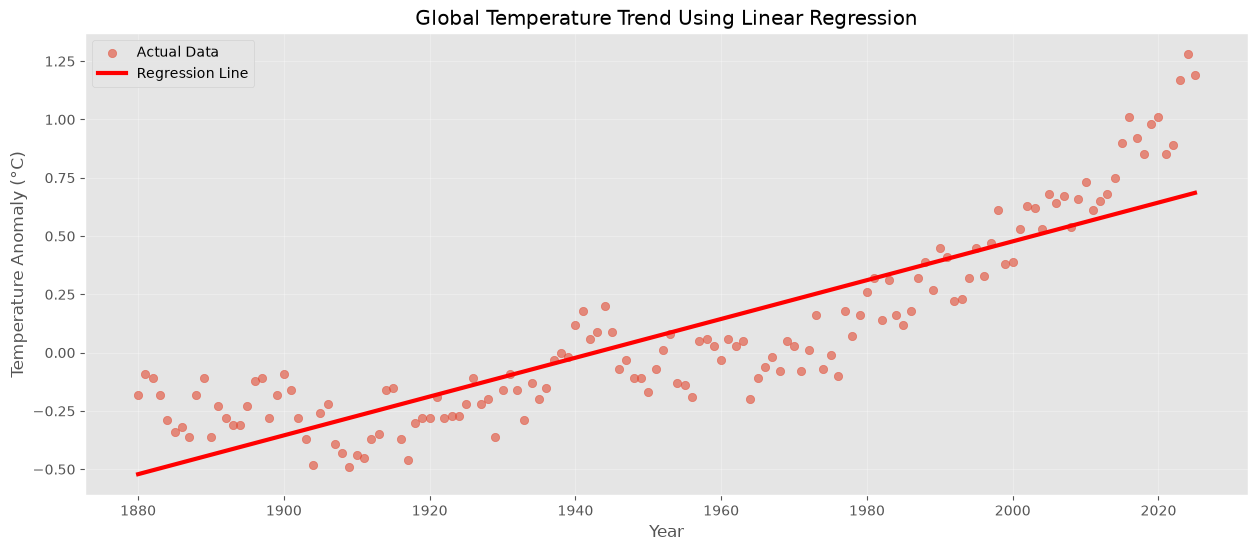

In [41]:
plt.figure(figsize=(15,6))

plt.scatter(
    trend_df["Year"],
    trend_df["Temperature_Anomaly"],
    alpha=0.6,
    label="Actual Data"
)

plt.plot(
    trend_df["Year"],
    trend_df["Predicted_Temperature"],
    color="red",
    linewidth=3,
    label="Regression Line"
)

plt.title("Global Temperature Trend Using Linear Regression")

plt.xlabel("Year")

plt.ylabel("Temperature Anomaly (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR / "regression_line.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
trend_df["Decade"] = (
    trend_df["Year"] // 10
) * 10

In [43]:
decade_summary = (
    trend_df
    .groupby("Decade")["Temperature_Anomaly"]
    .mean()
    .reset_index()
)

decade_summary

,Decade,Temperature_Anomaly
0,1880,-0.216
1,1890,-0.241
2,1900,-0.317
3,1910,-0.333
4,1920,-0.240
5,1930,-0.123
6,1940,0.042
7,1950,-0.047
8,1960,-0.031
9,1970,0.035


In [44]:
decade_summary.to_csv(
    TABLES_DIR /
    "decade_summary.csv",
    index=False
)

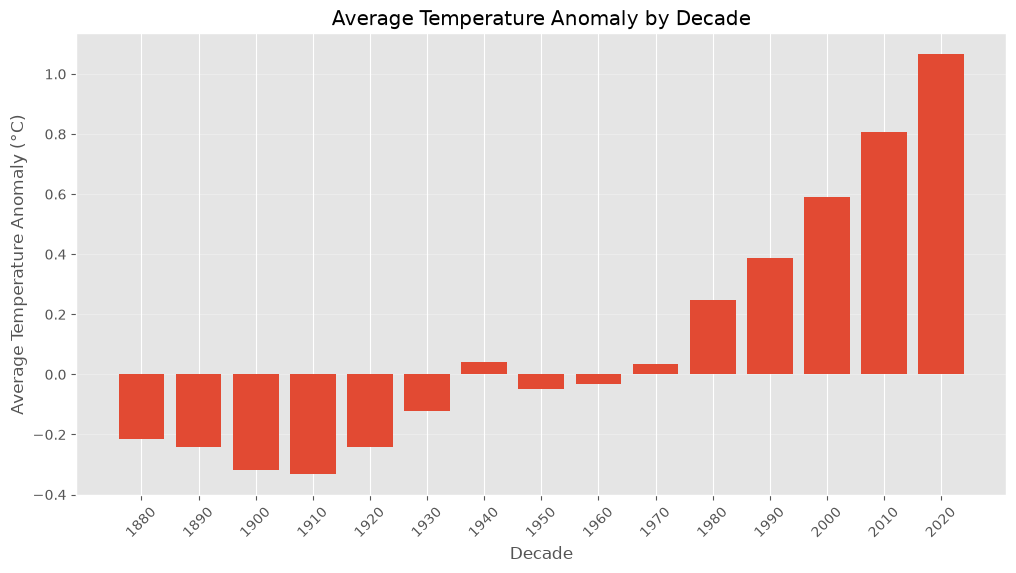

In [45]:
plt.figure(figsize=(12,6))

plt.bar(
    decade_summary["Decade"].astype(str),
    decade_summary["Temperature_Anomaly"]
)

plt.xticks(rotation=45)

plt.title("Average Temperature Anomaly by Decade")

plt.xlabel("Decade")

plt.ylabel("Average Temperature Anomaly (°C)")

plt.grid(axis="y", alpha=0.3)

plt.savefig(
    GRAPHS_DIR /
    "decade_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# No import needed - calculate_linear_trend is already available from CELL INDEX: 1


In [51]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

metrics = {
    "MSE": mean_squared_error(trend_df["Temperature_Anomaly"], trend_df["Predicted_Temperature"]),
    "RMSE": np.sqrt(mean_squared_error(trend_df["Temperature_Anomaly"], trend_df["Predicted_Temperature"])),
    "R2": r2_score(trend_df["Temperature_Anomaly"], trend_df["Predicted_Temperature"]),
    "MAE": np.mean(np.abs(trend_df["Temperature_Anomaly"] - trend_df["Predicted_Temperature"]))
}

metrics = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])
metrics

metrics.to_csv(
    TABLES_DIR / "regression_metrics.csv",
    index=False
)

metrics

,Metric,Value
0,MSE,0.037420
1,RMSE,0.193442
2,R2,0.766687
3,MAE,0.157775


In [52]:
evaluation_df = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Value"]
)

evaluation_df

,Metric,Value
0,Metric,0 MSE 1 RMSE 2 R2 3 MAE Name: ...
1,Value,0 0.037420 1 0.193442 2 0.766687 3 ...


In [53]:
evaluation_df.to_csv(
    TABLES_DIR / "model_evaluation.csv",
    index=False
)

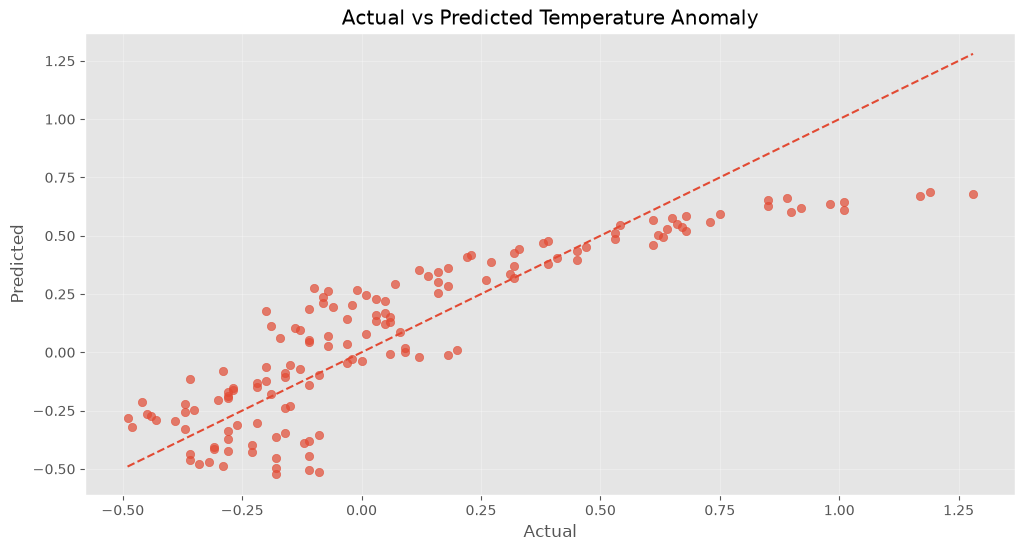

In [54]:
plt.figure(figsize=(12,6))

plt.scatter(
    trend_df["Temperature_Anomaly"],
    trend_df["Predicted_Temperature"],
    alpha=0.7
)

plt.plot(
    [
        trend_df["Temperature_Anomaly"].min(),
        trend_df["Temperature_Anomaly"].max()
    ],
    [
        trend_df["Temperature_Anomaly"].min(),
        trend_df["Temperature_Anomaly"].max()
    ],
    linestyle="--"
)

plt.title("Actual vs Predicted Temperature Anomaly")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR / "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
trend_df["Residual"] = (
    trend_df["Temperature_Anomaly"]
    - trend_df["Predicted_Temperature"]
)

In [ ]:
plt.figure(figsize=(14,6))

plt.scatter(
    trend_df["Year"],
    trend_df["Residual"],
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Year")
plt.ylabel("Residual")

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR / "residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()